<h1 style="text-align: center; font-family: 'menlo'; color: #FFF243; font-size:50px;">
  <span style="background-color: #FA9500; padding: 5px 10px; border-radius: 5px; display: inline-block;">
         Calibrating bias images
  </span>
</h1>

The purpose of calibrating bias images is threefold:

- <u>Subtract overscan</u> if you have decided your science will be better if you subtract overscan. See [this discussion of overscan](https://www.astropy.org/ccd-reduction-and-photometry-guide/v/dev/notebooks/01-08-Overscan.html) for some guidance.

- <u>Trim the overscan</u> region off of the image if it is present, regardless of whether or not you have chosen to subtract the overscan.

- <u>Combine the bias images</u> into a “combined” bias to be used in calibrating the rest of the images. The purpose of combining several images is to reduce as much as possible the read noise in the combined bias.

The approach in this notebook will be to <u>reduce a single image</u>, look at the effects the reduction step had on that image and then demonstrate <u>how to calibrate a folder</u> containing several images of that type.

In [1]:
from pathlib import Path
    # https://www.notion.so/Path-e-os-3acd10129584802e9ff1c52bd442e6fb?source=copy_link
from astropy.nddata import CCDData
from astropy.visualization import hist

import ccdproc as ccdp
import matplotlib.pyplot as plt
import numpy as np

from convenience_functions import show_image
plt.style.use('guide.mplstyle')

# Data for these examples

See the [Preface notebook](https://www.astropy.org/ccd-reduction-and-photometry-guide/v/dev/notebooks/00-00-Preface.html) for download links for all data.

# Example 1: With overscan subtraction

## Decide where to put your Example 1 calibrated images

Though it is possible to overwrite your raw data with calibrated images, this is not recommended. Here we create a folder called <span style="color: #d62495">example1-reduced</span> that will contain the calibrated data and create it if it doesn’t exist. 

In [2]:
calibrated_data = Path('.', 'example1-reduced') 
    # diretorio atual, nome da pasta -> .\example1-reduced
calibrated_data.mkdir(exist_ok=True)
    # mkdir = fazer a pasta -> make directory
    # exist_ok=True-> se a pasta já existir, não dá erro (e não faz nada) e continua

## Make an image file collection for the raw data

In [3]:
example_cryo_path = Path('example-cryo-LFC')
    # cria um objeto Path apontando para a pasta example-cryo-LFC
files = ccdp.ImageFileCollection(example_cryo_path)
    # files pode Listar todos os arquivos e suas informações (como foi feito abaixo);
    # filtrar apenas as imagens de um determinado tipo 
    # acessar os dados de cada imagem para processamento.

files.summary['file', 'imagetyp', 'filter', 'exptime', 'naxis1', 'naxis2']

file,imagetyp,filter,exptime,naxis1,naxis2
str14,str9,str2,float64,int64,int64
ccd.001.0.fits,BIAS,i',0.0,2080,4128
ccd.002.0.fits,BIAS,i',0.0,2080,4128
ccd.003.0.fits,BIAS,i',0.0,2080,4128
ccd.004.0.fits,BIAS,i',0.0,2080,4128
ccd.005.0.fits,BIAS,i',0.0,2080,4128
ccd.006.0.fits,BIAS,i',0.0,2080,4128
ccd.014.0.fits,FLATFIELD,g',70.001,2080,4128
ccd.015.0.fits,FLATFIELD,g',70.011,2080,4128
ccd.016.0.fits,FLATFIELD,g',70.001,2080,4128


In [4]:
darks_only = ccdp.ImageFileCollection(example_cryo_path / 'darks')
darks_only.summary['file', 'imagetyp', 'exptime']

file,imagetyp,exptime
str14,str4,float64
ccd.002.0.fits,BIAS,0.0
ccd.013.0.fits,DARK,300.0
ccd.014.0.fits,DARK,300.0
ccd.015.0.fits,DARK,300.0
ccd.017.0.fits,DARK,70.0
ccd.018.0.fits,DARK,70.0
ccd.019.0.fits,DARK,70.0
ccd.023.0.fits,DARK,7.0
ccd.024.0.fits,DARK,7.0


## Determine overscan region for the LFC Chip 0

Please see the discussion of this camera in [the Overscan notebook](https://www.astropy.org/ccd-reduction-and-photometry-guide/v/dev/notebooks/01-08-Overscan.ipynb#case-1-cryogenically-cooled-large-format-camera-lfc-at-palomar) for the appropriate overscan region to use for this camera. Note, in particular, that it differs from the value given in the <span style="color: #d62495">BIASSEC</span> keyword in the header of the images.
 *essa última frase ta dizendo que a região de overscan verdadeiramente útil começa na coluna 2055, não na 2049 como diz o cabeçalho.*

The astropy affiliated package [ccdproc](https://ccdproc.readthedocs.io/) provides two useful functions here:

- <span style="color: #d62495">subtract_overscan</span> for subtracting the overscan from the image, and

- <span style="color: #d62495">trim_image</span> for trimming off the overscan.

First, let’s see the values of <span style="color: #d62495">BIASSEC</span>, which <u>sometimes (but do not always) indicate that there is is overscan and which part of the chip is the overscan</u>, as well as the values of <span style="color: #d62495">CCDSEC</span>, which is sometimes <u>but not always present</u>, and indicates <u>which part of the chip light hit.</u>

Note that <u>neither of these are standard</u>; sometimes, for example, <span style="color: #d62495">trimsec</span> is used instead of <span style="color: #d62495">ccdsec</span>, and there are likely other variants. Some images may have neither keyword in the header. <u>This does not necessarily indicate that ovserscan isn’t present. The best advice is to carefully check the documentation for the camera you are using.</u>

In [5]:
files.summary['file', 'imagetyp', 'biassec', 'ccdsec', 'datasec'][0]
    # [0] = seleciona a primeira linha (índice 0) dessa tabela filtrada

file,imagetyp,biassec,ccdsec,datasec
str14,str9,str18,str15,str15
ccd.001.0.fits,BIAS,"[2049:2080,1:4127]","[1:2048,1:4128]","[1:2048,1:4128]"


The fits header claims the overscan extends from the $2049^{th}$ column to the end of the image (this is one-based indexing) and that the part of the image exposed to light extends over all rows and from the first column to the $2048^{th}$ column (again, this is one-indexed).

## FITS vs. Python indexing

There are two differences between FITS and Python in terms of indexing:

- Python indexes are zero-based (i.e., numbering starts at zero), while FITS indexes are one-based (i.e., numbering starts at one).

- The <u>order</u> of the indexes is swapped</u>.

For example, the **FITS** representation of the part of the chip exposed to light is <span style="color: #d62495">[1:2048,1:4128]</span>. To access that part of the data from a NumPy array in **Python**, switch the order so that the indexing looks like this: <span style="color: #d62495">[0:4128, 0:2048]</span> (or, more compactly <span style="color: #d62495">[:, :2048]</span>). Note that the ending indexes given here for Python are correct because the second part of a range (after the colon) is not included in the array slice. For example, <span style="color: #d62495">0:2048</span> starts at 0 (the first pixel) and goes up to but does not include 2048, so the last pixel included is <span style="color: #d62495">2047</span>) (the $2048^{th}$ pixel).

*Python (0) = [row, column] & [y, x] <br> FITS (1) = [column, row] & [x,y]*

As discussed in the [Overscan notebook](https://www.astropy.org/ccd-reduction-and-photometry-guide/v/dev/notebooks/01-08-Overscan.ipynb#case-1-cryogenically-cooled-large-format-camera-lfc-at-palomar), the useful overscan region <u>for this camera</u> starts at the $2055^{th}$ column, not column 2049 as indicated by the <span style="color: #d62495">BIASSEC</span> keyword in the header. This situation <u>is not unusual</u>; column 2049 is the first of the columns masked from light by the manufacturer, but there is some leakage into this region from the rest of the CCD.

<u>If you are going to use overscan you need to carefully examine the overscan in a few representative images to understand which part of the overscan to use.</u>

In what follows, we will use for the overscan the region (Python/NumPy indexing) <span style="color: #d62495">[:, 2055:]</span>.

## Subtract and then trim the overscan (one sample image)

Using <span style="color: #d62495">subtract_overscan</span> is reasonably concise, as shown in the cell below.

In [6]:
raw_biases = files.files_filtered(include_path=True, imagetyp='BIAS')
first_bias = CCDData.read(raw_biases[0], unit='adu')

In [7]:
bias_overscan_subtracted = ccdp.subtract_overscan(first_bias, overscan=first_bias[:, 2055:], median=True)

Next, we trim off the <u>full overscan region</u> (not just the part we used for subtracting overscan).

In [8]:
trimmed_bias=ccdp.trim_image(bias_overscan_subtracted[:, :2048])

Text(0.5, 1.0, 'Bias, overscan subtracted and trimmed')

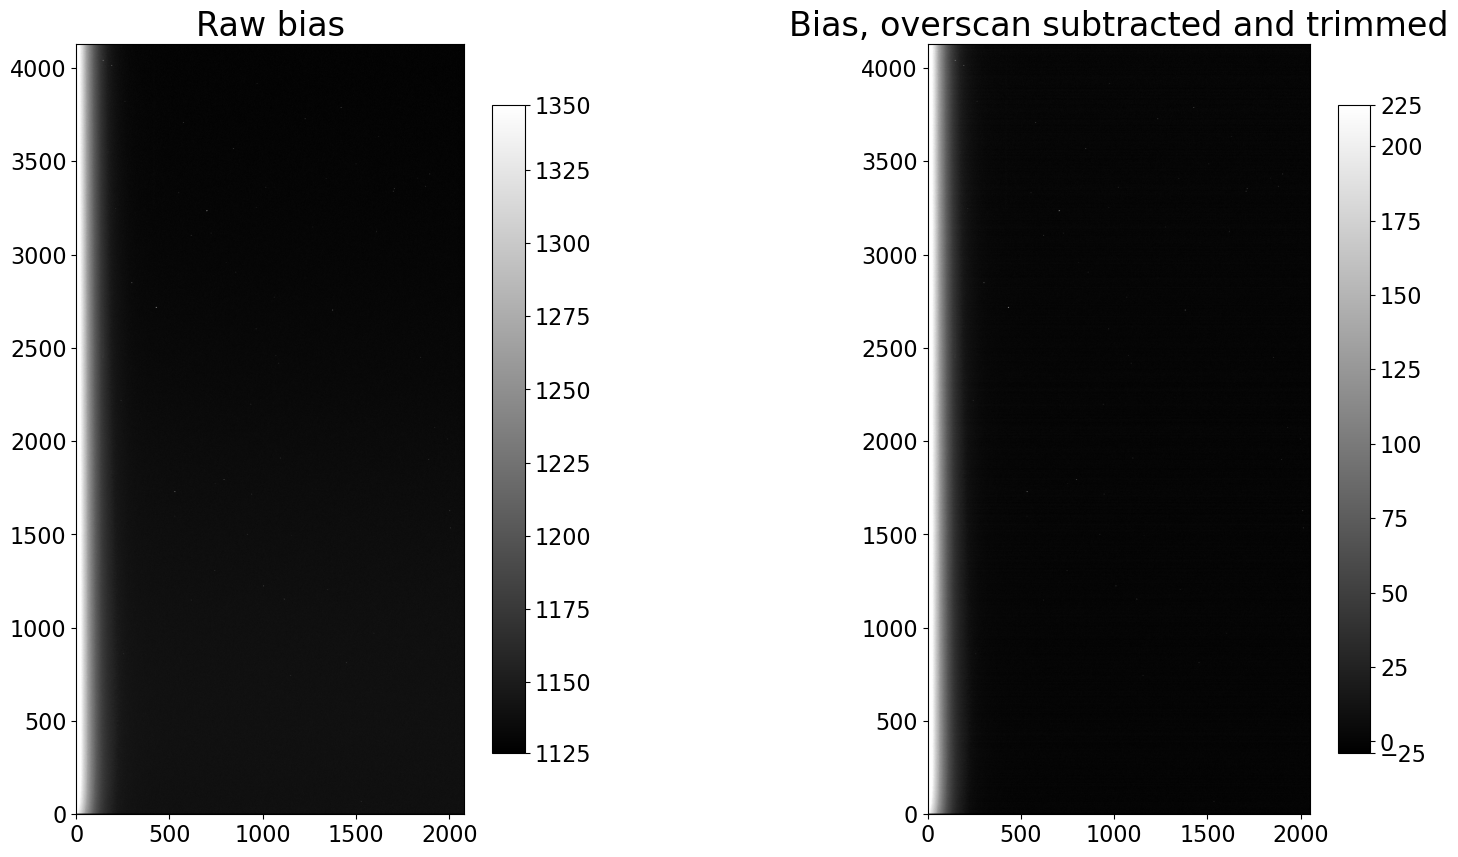

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

show_image(first_bias.data, cmap='gray', ax=ax1, fig=fig)
ax1.set_title('Raw bias')
show_image(trimmed_bias.data, cmap='gray', ax=ax2, fig=fig)
ax2.set_title('Bias, overscan subtracted and trimmed')

## Discussion 

Visually, the images look nearly identical before and after calibration. <u>The only prominent difference is a shift in the pixel values</u>, as one would expect from subtracting the same value from each pixel in an image. It simply shifts the zero point.

There is one other important difference between the images: <u>the input image uses 32MB of memory while the calibrated, overscan-subtracted image uses roughly 128MB. The input image is stored as unsigned 16-bit integers; the calibrated image is stored as floating point numbers, which default in Python to 64-bit floats.</u> The memory size is also the size the files will have when written to disk (ignoring any compression). You can reduce the memory and disk footprint by changing the <span style="color: #d62495">dtype</span> of the image: <span style="color: #d62495">trimmed_bias.data = trimmed_bias.data.astype('float32')</span> . <u>It is best to do this just before writing the image out because arithmetic operations on the image may convert its <span style="color: #d62495">dtype</span> back to <span style="color: #d62495">float64</span>.</u>

## Processing the folder of bias images for the LFC Chip 0

Processing each of the bias images <u>individually</u> would be tedious, at best. Instead, we can use the [ImageFileCollection](https://ccdproc.readthedocs.io/en/latest/ccdproc/image_management.html) we created above to loop over only the bias images, saving each in the folder <span style="color: #d62495">calibrated_data</span>. <u>In this example, the files are saved uncompressed because the Python library for compressing gzip files is extremely slow.</u>

*O código a seguir automatiza o processo de calibração para todas as imagens de bias de uma só vez. Em vez de processar cada arquivo manualmente, o computador faz isso num loop.*

In [10]:
    # files.ccd = iteração do ImageFileCollection
    # imagetyp = filtro
    # ccd_kwargs = dicionário que contém argumentos extras que serão passados
        # para a função que lê a imagem (CCDData.read): 
        # CCDData requires a unit for the image if it is not in the header 
    # return_fname = além do objeto ccd com os dados, também retorna o nome do arquivo (file_name)
for ccd, file_name in files.ccds(imagetyp='BIAS', ccd_kwargs={'unit': 'adu'}, return_fname=True):
    ccd = ccdp.subtract_overscan(ccd, overscan=ccd[:, 2055:], median=True) #subtract
    ccd = ccdp.trim_image(ccd[:, :2048]) #trim
    ccd.write(calibrated_data / file_name) #save

Let’s check that we really did get the images we expect by creating an [ImageFileCollection](https://ccdproc.readthedocs.io/en/latest/ccdproc/image_management.html) for the reduced folder and displaying the size of each image. We are expecting the images to be 2048 × 4128, and that there will be the same number of reduced bias images as input bias images (six).

In [11]:
reduced_images = ccdp.ImageFileCollection(calibrated_data)

In [13]:
reduced_images.summary['file', 'imagetyp', 'naxis1', 'naxis2']

file,imagetyp,naxis1,naxis2
str14,str4,int64,int64
ccd.001.0.fits,BIAS,2048,4128
ccd.002.0.fits,BIAS,2048,4128
ccd.003.0.fits,BIAS,2048,4128
ccd.004.0.fits,BIAS,2048,4128
ccd.005.0.fits,BIAS,2048,4128
ccd.006.0.fits,BIAS,2048,4128


# Example 2: No overscan subtraction, but trim the images

<u>If you are not subtracting overscan</u> then the only manipulation you may need to do is trimming the overscan from the images. If there is no overscan region in your images then even that is unnecessary.

## Decide where to put your calibrated Example 2 images

Though it is possible to overwrite your raw data with calibrated images, this is not recommended. Here we create a folder called <span style="color: #d62495">example2-reduced</span> that will contain the calibrated data and create it if it doesn’t exist.

In [14]:
calibrated_data = Path('.', 'example2-reduced')
calibrated_data.mkdir(exist_ok=True)

In [15]:
files = ccdp.ImageFileCollection('example-thermo-electric')
files.summary['file', 'imagetyp', 'filter', 'exptime', 'naxis1', 'naxis2']

file,imagetyp,filter,exptime,naxis1,naxis2
str31,str5,object,float64,int64,int64
AutoFlat-PANoRot-r-Bin1-001.fit,FLAT,r,1.0,4109,4096
AutoFlat-PANoRot-r-Bin1-002.fit,FLAT,r,1.0,4109,4096
AutoFlat-PANoRot-r-Bin1-003.fit,FLAT,r,1.0,4109,4096
AutoFlat-PANoRot-r-Bin1-004.fit,FLAT,r,1.0,4109,4096
AutoFlat-PANoRot-r-Bin1-005.fit,FLAT,r,1.0,4109,4096
AutoFlat-PANoRot-r-Bin1-006.fit,FLAT,r,1.02,4109,4096
AutoFlat-PANoRot-r-Bin1-007.fit,FLAT,r,1.06,4109,4096
AutoFlat-PANoRot-r-Bin1-008.fit,FLAT,r,1.11,4109,4096
AutoFlat-PANoRot-r-Bin1-009.fit,FLAT,r,1.16,4109,4096


## Determine overscan region for this camera

Please see the discussion of this camera in [the Overscan notebook](https://www.astropy.org/ccd-reduction-and-photometry-guide/v/dev/notebooks/01-08-Overscan.ipynb#case-2-thermo-electrically-cooled-apogee-aspen-cg16m) for a discussion of the overscan region of this camera. <u>The overscan for this camera is not useful but should be trimmed out at this stage.</u>

These headers have some information in the keywords <span style="color: #d62495">BIASSEC</span> and <span style="color: #d62495">TRIMSEC</span> indicating, in the FITS numbering convention, the overscan region and the science region of the chip.

In [16]:
files.summary['file', 'imagetyp', 'biassec', 'trimsec'][0]

file,imagetyp,biassec,trimsec
str31,str5,str11,str11
AutoFlat-PANoRot-r-Bin1-001.fit,FLAT,[4096:4109],"[1:4096, :]"


Based on this, and the decision not to subtract overscan for this camera, we will only need to trim the overscan region off of the images. See the discussion at [FITS vs. Python indexing](https://www.astropy.org/ccd-reduction-and-photometry-guide/v/dev/notebooks/02-02-Calibrating-bias-images.html#fits-vs-python-indexing), above, for some details about the difference between FITS and Python indexing. <u>Essentially, to get Python indexes from FITS, reverse the order and subtract one.</u>

## Trim the overscan (one sample image)

The function <span style="color: #d62495">trim_image</span> from [ccdproc](https://ccdproc.readthedocs.io/) removes a portion of the image and updates the image metadata as needed.

Below we get the first bias image.

In [18]:
raw_biases = files.files_filtered(include_path=True, imagetyp='BIAS')
first_bias = CCDData.read(raw_biases[0], unit='adu')

There are <u>two ways</u> of specifying the region to trim. One is to slice the image in Python; the other is to use the <span style="color: #d62495">fits_section</span> argument to <span style="color: #d62495">trim_image</span>.

The cell below uses a FITS-style section.

In [19]:
trimmed_bias_fits = ccdp.trim_image(first_bias, fits_section='[1:4096, :]')

The cell below does the same trimming as the one above, but with Python-style slicing.

In [20]:
trimmed_bias_python = ccdp.trim_image(first_bias[:, :4096])
np.testing.assert_allclose(trimmed_bias_python, trimmed_bias_fits)

## Processing the folder of bias images for Example 2

As in [Example 1](https://www.astropy.org/ccd-reduction-and-photometry-guide/v/dev/notebooks/02-02-Calibrating-bias-images.html#example-1-with-overscan-subtraction), above, we can use the [ImageFileCollection](https://ccdproc.readthedocs.io/en/latest/ccdproc/image_management.html) we created to loop over only the bias images, saving each in the folder <span style="color: #d62495">calibrated_data</span>.

In [21]:
for ccd, file_name in files.ccds(imagetyp='BIAS', return_fname=True):
    ccd = ccdp.trim_image(ccd[:, :4096]) #trim the overscan
    ccd.write(calibrated_data / file_name) #save

# Example 3: No overscan at all

If there is no overscan then there is, in principle, nothing to be done with the bias frames. It may be convenient to copy them to the directory with the rest of your reduced images. The code below does that.

In [22]:
calibrated_data = Path('.', 'example-3-reduced')
calibrated_data.mkdir(exist_ok=True)

biases = files.files_filtered(imagetyp='BIAS', include_path=True)

import shutil

for bias in biases:
    shutil.copy(bias, calibrated_data)

<h1 style="text-align: left; font-family: 'menlo'; color: #FA9500; font-size:40px;">
  <span style="background-color: #FFF243; padding: 5px 10px; border-radius: 5px; display: inline-block;">
         Notes
  </span>
</h1>

- Ali em 'Note, in particular, that it differs from the value given in the BIASSEC keyword in the header of the images.' foi colocado um comentário abaixo, mas adicionando mais coisas (mesmo que o notebook aborde isso):
    - Não dá pra confiar no cabeçalho sempre, tem que verificar os dados.
    - Pra determinar a região correta precisa examinar visualmente algumas imagens (`show_image`, como tem no notebook); procurar onde a 'assinatura' do overscan começa de fato (uma faixa com valores característicos);

- Importante:
    - Python começa com 0 e FITS começa com 1.
    - FITS é [coluna, linha] e [x,y], Python é [linha, coluna] e [y, x].
    - Nesse exemplo, os arquivos são salvos uncompressed pk a bibloteca do Python pra compressing gzip arquivos é extremamente lenta.
 
---
<h1 style="text-align: left; font-family: 'menlo'; color: #FA9500; font-size:40px;">
  <span style="background-color: #FFF243; padding: 5px 10px; border-radius: 5px; display: inline-block;">
         Links
  </span>
</h1>

https://github.com/sh4rkNy/astropy-coisas/tree/main<br>https://github.com/astropy/ccd-reduction-and-photometry-guide<br>https://www.astropy.org/ccd-reduction-and-photometry-guide/v/dev/notebooks/02-02-Calibrating-bias-images.html